# Run 2 vs Run 3 — Domain Classifier (Two-Sample Test)

A separate, lightweight XGBoost model whose only job is to tell **Run 2**
signal events apart from **Run 3** signal events (signal_ggF + signal_VBF).
This is independent from the signal-vs-background classifiers trained in
`First_Training.ipynb` — nothing there is touched or reused as a model.

**Features:** the same 20 Optuna-tuned, decorrelated features used by the
Run-2 signal-vs-background BDT (`optuna_features_run2.json`) — not the full
set of common branches.

**Label convention:** Run 2 = 0, Run 3 = 1.

**How to read the resulting AUC:**
- AUC ≈ 0.5 → the classifier can't tell the runs apart → the feature
  distributions are effectively the same between Run 2 and Run 3.
- AUC well above 0.5 → there is a genuine distribution shift between the
  runs, and `AUC − 0.5` is roughly the effect size of that shift.

In [ ]:
import uproot, pandas as pd, numpy as np
from pathlib import Path
import json
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ---- Configuration ----------------------------------------------------------
# Only the SIGNAL processes (ggF + VBF) - this compares Run 2 vs Run 3, it is
# NOT a signal-vs-background classifier. Same tree name / preselection as
# First_Training.ipynb, so the comparison reflects the phase space that
# actually enters the analysis.

BASE_DIR_R2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_R3 = Path("PPSSP_2026/1l2tau/run3")
TREE_NAME    = "AnalysisMiniTree"
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

SIGNAL_FILES = {
    "signal_ggF": "signal_ggF.root",
    "signal_VBF": "signal_VBF.root",
}

WEIGHT_BRANCH = "weights"  # raw per-event branch, used AS-IS as sample_weight
                            # (NOT weight * weights, unlike w_phys elsewhere)

# ---- Feature list: reuse the exact 20 features from First_Training.ipynb ---
# This is the Run-2 Optuna-tuned, decorrelated feature set (OPTUNA_FEATURES),
# persisted there as optuna_features_run2.json. Using the SAME 20 features the
# signal-vs-background BDT was trained on tells us whether the variables that
# actually feed the analysis differ between Run 2 and Run 3.
FEATURES_PATH = BASE_DIR_R2 / "optuna_features_run2.json"
with open(FEATURES_PATH) as f:
    domain_features = json.load(f)

print(f"Loaded {len(domain_features)} features from {FEATURES_PATH}:")
print(domain_features)

# Sanity check: confirm every one of these branches exists in ALL FOUR signal
# files (ggF + VBF, Run2 + Run3) before we try to read them.

common = None
for base_dir in (BASE_DIR_R2, BASE_DIR_R3):
    for fname in SIGNAL_FILES.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common = keys if common is None else common & keys

missing = [f for f in domain_features if f not in common]
if missing:
    raise ValueError(f"Features missing from one or more signal files: {missing}")

Loaded 20 features from PPSSP_2026/1l2tau/run2/optuna_features_run2.json:
['HT_tau', 'dR_t1t2', 'm_t1t2', 'met_sumet', 'dR_l1j1', 'm_l1j', 'tau2_pt', 'met_met', 'm_ttl', 'm_l1j1', 'm_l1t', 'dR_t1t2_l1', 'tau1_eta', 'dR_l1j2', 'dR_l1t', 'tau2_eta', 'l1_eta', 'dR_l1t2', 'l1_e', 'm_t2j1']


In [3]:
# ---- Extraction loop ---------------------------------------------------------
# Label: Run 2 = 0, Run 3 = 1 (the target of THIS classifier only).

frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2), (1, "Run 3", BASE_DIR_R3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        df["process"]   = proc
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(domain_data)} events "
      f"(Run 2 = {(domain_data.run_label == 0).sum()}, Run 3 = {(domain_data.run_label == 1).sum()})")

Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection

Total: 293764 events (Run 2 = 88714, Run 3 = 205050)


In [4]:
# ---- Post-concat cleaning ----------------------------------------------------
# 1) Constant / empty features -> drop (zero variance carries no separation power)

nun = domain_data[domain_features].nunique()
const = nun[nun <= 1].index.tolist()
domain_features = [f for f in domain_features if f not in const]
domain_data = domain_data.drop(columns=const)
print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

# 2) Sentinel values (e.g. -999) -> NaN; XGBoost routes NaNs natively.
for f in domain_features:
    m = domain_data[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        domain_data[f] = domain_data[f].mask(m)

print(f"\n{len(domain_features)} final features")

Dropped 0 constant/empty features:
  []

20 final features


In [5]:
# ---- Sanity checks: weight sums & negative-weight fractions ------------------
# Comparable total weight -> comparable effective normalization between runs.
# Negative weights are reported here but events are NOT dropped for that reason
# (Sherpa NLO interference effects are physical, not a data quality issue).

for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data.loc[domain_data.run_label == run_label, WEIGHT_BRANCH]
    total_w  = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")

Run 2: sum(weights) =    1848.0950 | negative-weight fraction =  4.58% | n_events = 88714
Run 3: sum(weights) =    5227.1216 | negative-weight fraction =  5.80% | n_events = 205050


In [7]:
# ---- Build training arrays ----------------------------------------------------
X = domain_data[domain_features]
y = domain_data["run_label"].to_numpy()
w_raw = domain_data[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS

# Negative sample weights corrupt XGBoost's gradient computation (same issue
# noted for w_phys in First_Training.ipynb), so training and AUC both use
# |weights|. Events are KEPT either way - only the sign is dropped, and the
# fraction of affected events was already reported above.

w_abs = np.abs(w_raw)

# --- Class balance --------------------------------------------------------
# Run 2 and Run 3 have different total weight (see sanity check above);
# without correcting for it, the run with the larger total weight would
# dominate the loss and the AUC would partly reflect a normalization
# difference rather than a genuine shape difference. We rescale per-event
# weights so both runs contribute equal total weight, rather than using
# scale_pos_weight, because we already need a custom per-event array to
# honor the "raw weights branch" requirement - stacking scale_pos_weight on
# top would double-apply the correction.

w_fit = w_abs.copy()
sum_r2, sum_r3 = w_fit[y == 0].sum(), w_fit[y == 1].sum()
w_fit[y == 1] *= sum_r2 / sum_r3
w_fit *= len(w_fit) / w_fit.sum()   # normalize mean weight to 1

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2 / sum_r3:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit[y == 0].sum() / w_fit[y == 1].sum():.3f}")

Run2/Run3 total-weight ratio before balancing: 0.351
Run2/Run3 total-weight ratio after balancing:  1.000


In [8]:
# ---- Stratified K-Fold cross-validation --------------------------------------
# AUC is computed ONLY on each held-out fold, never on the data its model was
# trained on. Mean ± std across folds gives both the effect size (how
# distinguishable Run2/Run3 are) and its fold-to-fold uncertainty.
#
# IMPORTANT: no early stopping / eval_set here. Early-stopping on the SAME
# fold used for the reported AUC would let XGBoost pick best_iteration to
# maximize performance on the exact data being scored - a leak that biases
# the AUC upward. Since the whole point here is "is AUC ~ 0.5", even a small
# upward bias can manufacture apparent Run2/Run3 separation. A fixed
# n_estimators, with a fold trained (and scored) with zero peeking at idx_te,
# is the clean choice - the model is already regularized (shallow depth,
# subsample/colsample < 1, reg_lambda), so residual over/underfit hurts the
# held-out AUC symmetrically instead of inflating it.

N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_aucs = []
for fold, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    fold_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,            # shallow: lightweight domain check, not the main BDT
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )
    fold_model.fit(
        X.iloc[idx_tr], y[idx_tr],
        sample_weight=w_fit[idx_tr],
        verbose=False,
    )

    pred = fold_model.predict_proba(X.iloc[idx_te])[:, 1]
    fold_auc = roc_auc_score(y[idx_te], pred, sample_weight=w_abs[idx_te])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS}: weighted AUC = {fold_auc:.4f}")

fold_aucs = np.array(fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS} folds: {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")

Fold 1/5: weighted AUC = 0.5359
Fold 2/5: weighted AUC = 0.5481
Fold 3/5: weighted AUC = 0.5492
Fold 4/5: weighted AUC = 0.5454
Fold 5/5: weighted AUC = 0.5449

Mean weighted AUC across 5 folds: 0.5447 ± 0.0047
(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)


Held-out AUC of this single interpretation model: 0.5359 (compare to the 5-fold mean above)

Top 20 features separating Run 2 / Run 3 (by total gain):
             total_gain  gain_frac  weight
HT_tau      7999.866211   0.117613   395.0
l1_e        7455.209473   0.109605   308.0
met_sumet   6544.036133   0.096210   326.0
tau2_pt     5139.678223   0.075563   320.0
l1_eta      3775.975586   0.055514   260.0
tau1_eta    3199.032227   0.047032   244.0
m_t2j1      3096.722900   0.045528   221.0
dR_l1j2     2830.795898   0.041618   214.0
m_l1j       2691.443848   0.039569   212.0
m_t1t2      2600.138428   0.038227   192.0
dR_t1t2     2562.446289   0.037673   203.0
dR_l1j1     2560.507812   0.037644   201.0
m_ttl       2553.158447   0.037536   180.0
met_met     2443.481689   0.035924   194.0
tau2_eta    2355.378906   0.034628   190.0
m_l1t       2256.170654   0.033170   164.0
m_l1j1      2151.244873   0.031627   175.0
dR_t1t2_l1  2139.303955   0.031452   160.0
dR_l1t2     1892.579102   0.0278

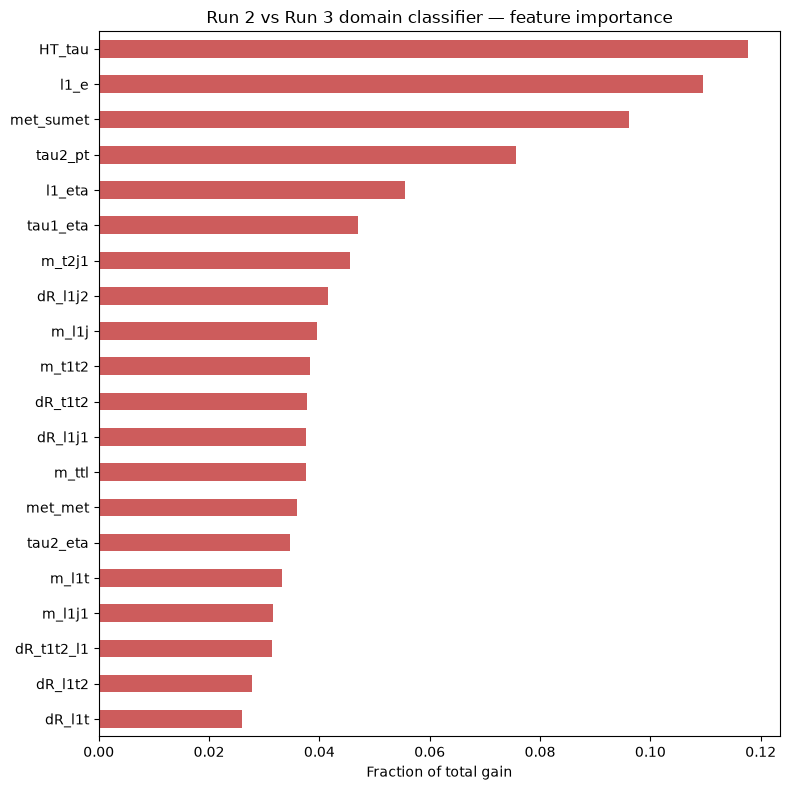

In [ ]:
# ---- Final model (single split) + feature importance -------------------------
# The k-fold result above is the AUC estimate to quote. This single model is
# only to get one clean feature-importance / SHAP picture - averaging across
# 5 separate fold-models would be messier to interpret.

train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X, y))

# No early stopping / eval_set here either - test_idx must stay completely
# unseen during training for auc_test below to be a genuine held-out number
# (same leakage reasoning as the k-fold loop above).

final_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

final_model.fit(
    X.iloc[train_idx], y[train_idx],
    sample_weight=w_fit[train_idx],
    verbose=False,
)

pred_test = final_model.predict_proba(X.iloc[test_idx])[:, 1]
auc_test = roc_auc_score(y[test_idx], pred_test, sample_weight=w_abs[test_idx])

print(f"Held-out AUC of this single interpretation model: {auc_test:.4f} "
      f"(compare to the {N_FOLDS}-fold mean above)")

# --- Feature importance: which variables drive the Run2/Run3 difference -----
booster = final_model.get_booster()
imp = pd.DataFrame({
    t: booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(domain_features).fillna(0.0)

imp = imp.sort_values("total_gain", ascending=False)
imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()

TOP_N = 20

print(f"\nTop {TOP_N} features separating Run 2 / Run 3 (by total gain):")
print(imp[["total_gain", "gain_frac", "weight"]].head(TOP_N).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
imp["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="indianred")
ax.set_xlabel("Fraction of total gain")
ax.set_title("Run 2 vs Run 3 domain classifier — feature importance")
plt.tight_layout()
plt.show()

In [21]:
# ---- SHAP values -------

import shap

# Subsample for speed; TreeExplainer is exact for tree models, so a
# moderate sample is enough to see the global pattern.
    
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
X_shap = X.iloc[sample_idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, max_display=20, show=True)



NameError: name 'final_model' is not defined

## Run 2 vs Run 3 — all processes (signal + background)

Repeat the same two-sample test independently for **every** simulated process
(not just the combined signal), so we can see whether Run2/Run3 differences
are localized to specific backgrounds or are a general feature of the
production. Same 20 features, same preselection, same weight handling as
above — just looped over every ROOT file.

Outputs:
- `run2_vs_run3_auc_summary.csv` — one row per process (event counts, weight
  sums, negative-weight fractions, mean weighted AUC ± std, top feature).
- `run2_vs_run3_plots/<process>_importance.png` — one feature-importance plot
  per process.

In [9]:
# ---- Configuration: every process, and where results/plots are written ----
PLOTS_DIR = Path("run2_vs_run3_plots")
PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_CSV = Path("run2_vs_run3_auc_summary.csv")

# Same processes/filenames as First_Training.ipynb's `files` dict (signal AND
# background) - the sig/bkg label doesn't matter here, only the filename.
ALL_FILES = {
    "signal_ggF": "signal_ggF.root",
    "signal_VBF": "signal_VBF.root",
    "Diboson":    "diboson.root",
    "Zjets":      "Zjets.root",
    "Wjets":      "Wjets.root",
    "ttbar":      "ttbar.root",
    "tops":       "tops.root",
    "SingleH":    "singleH.root",
    "Vgamma":     "Vgamma.root",
    "VVV":        "VVV.root",
}

print(f"Will run the Run2-vs-Run3 domain classifier on {len(ALL_FILES)} processes:")
print(list(ALL_FILES))

Will run the Run2-vs-Run3 domain classifier on 10 processes:
['signal_ggF', 'signal_VBF', 'Diboson', 'Zjets', 'Wjets', 'ttbar', 'tops', 'SingleH', 'Vgamma', 'VVV']


In [10]:
# ---- Reusable single-process Run2-vs-Run3 domain classifier ----------------
# Lighter hyperparameters than the combined-signal test above (fewer folds,
# fewer trees) since this runs 10 times - it's a scan, not the final result.

def run_two_sample_test(process_name, fname, n_folds=3, n_estimators=200,
                         plots_dir=PLOTS_DIR):
    """Run the Run2-vs-Run3 domain classifier for a single process (one ROOT
    file per run). Saves a feature-importance PNG and returns a summary dict.

    No early stopping / eval_set is used for the fold AUCs: early-stopping on
    the same fold that gets scored would bias the AUC upward, which matters a
    lot when the whole point is testing "AUC ~ 0.5". Fixed n_estimators with
    the existing regularization (shallow depth, subsample/colsample, L2) is
    the clean choice instead.
    """
    # ---- Load & concatenate this process's Run2 + Run3 files ---------------
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_R2), (1, BASE_DIR_R3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)

    # Sentinel -> NaN only (no constant-feature dropping here, so every
    # process uses the exact same 20 features - keeps results comparable).
    for feat in domain_features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())

    X_proc = data[domain_features]
    y_proc = data["run_label"].to_numpy()
    w_raw_proc = data[WEIGHT_BRANCH].to_numpy()
    w_abs_proc = np.abs(w_raw_proc)

    sum_w_r2 = w_raw_proc[y_proc == 0].sum()
    sum_w_r3 = w_raw_proc[y_proc == 1].sum()
    neg_frac_r2 = (w_raw_proc[y_proc == 0] < 0).mean() if n_r2 else np.nan
    neg_frac_r3 = (w_raw_proc[y_proc == 1] < 0).mean() if n_r3 else np.nan

    # Class-balance the |weights| (same rationale as the combined-signal test)
    w_fit_proc = w_abs_proc.copy()
    sum_abs_r2, sum_abs_r3 = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_abs_r2 > 0 and sum_abs_r3 > 0:
        w_fit_proc[y_proc == 1] *= sum_abs_r2 / sum_abs_r3
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    # ---- Stratified K-Fold weighted AUC (held-out folds only) --------------
    # No early stopping / eval_set: the held-out fold (idx_te) must never be
    # seen during training, or XGBoost picks best_iteration to maximize AUC
    # on the exact data being scored - an upward-biasing leak that matters a
    # lot here since the deliverable is "is AUC ~ 0.5".
    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fold_model = xgb.XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            )
            fold_model.fit(
                X_proc.iloc[idx_tr], y_proc[idx_tr],
                sample_weight=w_fit_proc[idx_tr],
                verbose=False,
            )
            pred = fold_model.predict_proba(X_proc.iloc[idx_te])[:, 1]
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc  = float(fold_aucs.std())  if len(fold_aucs) else np.nan

    # ---- One model on the full data, just for feature importance / PNG -----
    final = xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )
    final.fit(X_proc, y_proc, sample_weight=w_fit_proc, verbose=False)

    booster_proc = final.get_booster()
    imp_proc = pd.DataFrame({
        "total_gain": booster_proc.get_score(importance_type="total_gain")
    }).reindex(domain_features).fillna(0.0)
    imp_proc = imp_proc.sort_values("total_gain", ascending=False)
    imp_proc["gain_frac"] = imp_proc["total_gain"] / imp_proc["total_gain"].sum()

    fig, ax = plt.subplots(figsize=(8, 8))
    imp_proc["gain_frac"][::-1].plot.barh(ax=ax, color="teal")
    ax.set_xlabel("Fraction of total gain")
    ax.set_title(f"Run 2 vs Run 3 — {process_name} — feature importance")
    plt.tight_layout()
    fig.savefig(plots_dir / f"{process_name}_importance.png", dpi=150)
    plt.close(fig)

    # Sentinel->NaN doesn't neutralize a feature as a discriminator: if the
    # NaN *fraction* itself differs between runs, the model can separate
    # Run2/Run3 on "is this feature missing" rather than its real value. Track
    # the NaN fraction of the TOP feature per run so a suspiciously high AUC
    # dominated by one variable can be sanity-checked before trusting it.
    
    top_feature = imp_proc.index[0] if len(imp_proc) else None
    if top_feature is not None:
        nan_frac_r2 = data.loc[data.run_label == 0, top_feature].isna().mean()
        nan_frac_r3 = data.loc[data.run_label == 1, top_feature].isna().mean()
    else:
        nan_frac_r2 = nan_frac_r3 = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds) | "
          f"top feature = {top_feature} (NaN frac Run2={nan_frac_r2:.1%}, Run3={nan_frac_r3:.1%})")

    return {
        "process": process_name,
        "n_run2": n_r2,
        "n_run3": n_r3,
        "sum_weights_run2": sum_w_r2,
        "sum_weights_run3": sum_w_r3,
        "neg_weight_frac_run2": neg_frac_r2,
        "neg_weight_frac_run3": neg_frac_r3,
        "n_folds": n_splits,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "top_feature": top_feature,
        "top_feature_gain_frac": imp_proc["gain_frac"].iloc[0] if len(imp_proc) else np.nan,
        "top_feature_nan_frac_run2": nan_frac_r2,
        "top_feature_nan_frac_run3": nan_frac_r3,
    }

In [11]:
# ---- Run the scan over every process and export the summary ---------------
results = [run_two_sample_test(proc, fname) for proc, fname in ALL_FILES.items()]

results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV, index=False)

print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV}")
print(f"Saved {len(ALL_FILES)} feature-importance PNGs -> {PLOTS_DIR}/")
results_df

signal_ggF  : Run2 =   67075 | Run3 =  191580 | weighted AUC = 0.5433 ± 0.0016 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
signal_VBF  : Run2 =   21639 | Run3 =   13470 | weighted AUC = 0.5101 ± 0.0029 (3 folds) | top feature = tau1_eta (NaN frac Run2=0.0%, Run3=0.0%)
Diboson     : Run2 =  312600 | Run3 =  628676 | weighted AUC = 0.5421 ± 0.0013 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
Zjets       : Run2 =  141863 | Run3 =  157073 | weighted AUC = 0.5597 ± 0.0026 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
Wjets       : Run2 =   31272 | Run3 =   39061 | weighted AUC = 0.5407 ± 0.0077 (3 folds) | top feature = met_sumet (NaN frac Run2=0.0%, Run3=0.0%)
ttbar       : Run2 =    7335 | Run3 =   40832 | weighted AUC = 0.5461 ± 0.0014 (3 folds) | top feature = HT_tau (NaN frac Run2=0.0%, Run3=0.0%)
tops        : Run2 =   62238 | Run3 =  161226 | weighted AUC = 0.5299 ± 0.0042 (3 folds) | top feature = met_sumet (NaN frac Run2=0

,process,n_run2,n_run3,sum_weights_run2,sum_weights_run3,neg_weight_frac_run2,neg_weight_frac_run3,n_folds,mean_auc,std_auc,top_feature,top_feature_gain_frac,top_feature_nan_frac_run2,top_feature_nan_frac_run3
0,SingleH,11124,38425,3.962862e+04,2.468117e+05,0.004764,0.003149,3,0.582373,0.016148,m_l1j,0.064391,0.0,0.0
1,VVV,14028,40254,4.424491e+02,8.699266e+04,0.002067,0.010782,3,0.579746,0.005484,HT_tau,0.174390,0.0,0.0
2,Zjets,141863,157073,1.382527e+11,1.739534e+11,0.153824,0.148237,3,0.559657,0.002637,HT_tau,0.146651,0.0,0.0
3,ttbar,7335,40832,5.328624e+06,1.009084e+07,0.004090,0.002914,3,0.546132,0.001371,HT_tau,0.092793,0.0,0.0
4,signal_ggF,67075,191580,1.820433e+03,5.209738e+03,0.060246,0.062032,3,0.543276,0.001575,HT_tau,0.145815,0.0,0.0
5,Diboson,312600,628676,1.670813e+10,3.256988e+10,0.061590,0.061055,3,0.542139,0.001297,HT_tau,0.161541,0.0,0.0
6,Wjets,31272,39061,3.630890e+11,5.163083e+11,0.158129,0.148255,3,0.540673,0.007675,met_sumet,0.118762,0.0,0.0
7,tops,62238,161226,2.345940e+06,8.477411e+06,0.363363,0.358974,3,0.529949,0.004160,met_sumet,0.071215,0.0,0.0
8,Vgamma,21510,14295,1.350674e+10,9.171024e+09,0.078615,0.078699,3,0.520556,0.021632,met_sumet,0.084203,0.0,0.0
9,signal_VBF,21639,13470,2.766178e+01,1.738380e+01,0.001155,0.001039,3,0.510143,0.002859,tau1_eta,0.065162,0.0,0.0


## Run 2 vs Run 3 — 2 Lepton 2 Tau channel

Same two-sample domain-classifier test as above, repeated for the **2l2tau**
channel (`PPSSP_2026/2l2tau/run2` / `run3`).

**Preselection** (see `README.md`): `n_b_jet == 0`, opposite-sign leptons
(`l1_charge * l2_charge < 0`), `mZ_cut > 0`.

**Features:** there is no `First_Training.ipynb`-equivalent for 2l2tau yet, so
no Optuna-tuned feature list exists to reuse. Instead this uses the same
leakage-free branch-selection policy that built the *initial* (pre-Optuna)
feature list in `First_Training.ipynb`: every branch common to all processes,
minus weights/scale-factors, truth/fake/anti-tau bookkeeping, RNN/ID scores
and preselection constants. `xgb_score` (a pre-existing classifier output
found only in the 2l2tau files) is excluded too, since it isn't a raw
kinematic variable.

Everything else — label convention (Run 2 = 0, Run 3 = 1), raw `weights`
branch used as-is, |weights| for training/AUC, per-run weight balancing,
5-fold CV with no early stopping — is identical to the 1l2tau section.


In [10]:

# ---- Configuration (2 Lepton 2 Tau) -----------------------------------------
BASE_DIR_R2_2L = Path("PPSSP_2026/2l2tau/run2")
BASE_DIR_R3_2L = Path("PPSSP_2026/2l2tau/run3")
PRESELECTION_2L = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

SIGNAL_FILES_2L = {
    "signal_ggF": "signal_ggF.root",
    "signal_VBF": "signal_VBF.root",
}

# ---- Feature list: no Optuna-tuned list exists for this channel yet, so we
# rebuild the same leakage-free candidate-feature policy used for the initial
# (pre-Optuna) feature list in First_Training.ipynb, adapted to 2l2tau branch
# names (pass2l2tau instead of pass1l2tau, hhml_subChannelFlavor casing, the
# lep-pair OS flag, etc.) plus xgb_score, a pre-existing model output that has
# no equivalent in the 1l2tau files and isn't a raw kinematic variable.

BLOCK_SUBSTR_2L = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                   "dsid", "eventnumber", "_rnntight", "_isos", "_d0sig","pass_"]
BLOCK_EXACT_2L = {"n_b_jet", "pass2l2tau", "hhml_subchannelflavor",
                  "tau1_rnnjetscoresigtrans", "tau2_rnnjetscoresigtrans",
                  "xgb_score"}

def is_feature_2l(branch: str) -> bool:
    lb = branch.lower()
    return lb not in BLOCK_EXACT_2L and not any(s in lb for s in BLOCK_SUBSTR_2L)

# Build the feature list from branches COMMON to all (signal) files, same as
# the combined-signal test above.
common_2l = None
for base_dir in (BASE_DIR_R2_2L, BASE_DIR_R3_2L):
    for fname in SIGNAL_FILES_2L.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common_2l = keys if common_2l is None else common_2l & keys

domain_features_2l = sorted(b for b in common_2l if is_feature_2l(b))
print(f"{len(domain_features_2l)} candidate features for 2l2tau "
      f"(common to all signal files, leakage-free):")
print(domain_features_2l)


93 candidate features for 2l2tau (common to all signal files, leakage-free):
['HT', 'HT_all', 'HT_jet', 'HT_lep', 'HT_lepMET', 'HT_tau', 'SumPt_l1j', 'SumPt_l1j1', 'SumPt_t1t2', 'dR_j1j2', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'dR_l1j1', 'dR_l1j2', 'dR_l1l2', 'dR_l1t', 'dR_l1t1', 'dR_l1t2', 'dR_l2j1', 'dR_l2j2', 'dR_l2t1', 'dR_l2t2', 'dR_t1j1', 'dR_t1j2', 'dR_t1t2', 'dR_t1t2_l1', 'dR_t2j1', 'dR_t2j2', 'j1_e', 'j1_eta', 'j1_phi', 'j1_pt', 'j2_e', 'j2_eta', 'j2_phi', 'j2_pt', 'l1_charge', 'l1_e', 'l1_eta', 'l1_pdg', 'l1_phi', 'l1_pt', 'l1_z0sintheta', 'l2_charge', 'l2_e', 'l2_eta', 'l2_pdg', 'l2_phi', 'l2_pt', 'l2_z0sintheta', 'low_mass_cut', 'mZ_cut', 'mZ_veto', 'mZreq', 'm_all', 'm_j1j2', 'm_l1j', 'm_l1j1', 'm_l1j2', 'm_l1l2', 'm_l1t', 'm_l1t1', 'm_l1t2', 'm_l2j1', 'm_l2j2', 'm_l2t1', 'm_l2t2', 'm_t1j1', 'm_t1j2', 'm_t1t2', 'm_t2j1', 'm_t2j2', 'm_ttl', 'met_met', 'met_phi', 'met_sumet', 'n_jet', 'n_lep', 'tau1_base_id', 'tau1_charge', 'tau1_decayMode', 'tau1_eta', 'tau1_nprong', 't

In [12]:

# ---- Extraction loop (2l2tau) -----------------------------------------------
# Label: Run 2 = 0, Run 3 = 1, same convention as the 1l2tau section.

frames_2l = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2_2L), (1, "Run 3", BASE_DIR_R3_2L)]:
    for proc, fname in SIGNAL_FILES_2L.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features_2l + [WEIGHT_BRANCH], cut=PRESELECTION_2L, library="pd")
        df["run_label"] = run_label
        df["process"]   = proc
        frames_2l.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data_2l = pd.concat(frames_2l, ignore_index=True)
print(f"\nTotal: {len(domain_data_2l)} events "
      f"(Run 2 = {(domain_data_2l.run_label == 0).sum()}, Run 3 = {(domain_data_2l.run_label == 1).sum()})")


Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection
Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection

Total: 137905 events (Run 2 = 37557, Run 3 = 100348)


In [13]:

# ---- Post-concat cleaning (2l2tau) ------------------------------------------
nun_2l = domain_data_2l[domain_features_2l].nunique()
const_2l = nun_2l[nun_2l <= 1].index.tolist()
domain_features_2l = [f for f in domain_features_2l if f not in const_2l]
domain_data_2l = domain_data_2l.drop(columns=const_2l)

print(f"Dropped {len(const_2l)} constant/empty features:\n  {sorted(const_2l)}")

for f in domain_features_2l:
    m = domain_data_2l[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        domain_data_2l[f] = domain_data_2l[f].mask(m)

print(f"\n{len(domain_features_2l)} final features")


Dropped 9 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'low_mass_cut', 'mZ_cut', 'mZreq', 'n_lep', 'tau1_base_id', 'tau2_base_id']

84 final features


In [14]:

# ---- Sanity checks: weight sums & negative-weight fractions (2l2tau) -------
for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data_2l.loc[domain_data_2l.run_label == run_label, WEIGHT_BRANCH]
    total_w  = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")


Run 2: sum(weights) =     871.9282 | negative-weight fraction =  5.24% | n_events = 37557
Run 3: sum(weights) =    2634.0020 | negative-weight fraction =  5.94% | n_events = 100348


In [15]:

# ---- Build training arrays (2l2tau) -----------------------------------------

X_2l = domain_data_2l[domain_features_2l]
y_2l = domain_data_2l["run_label"].to_numpy()
w_raw_2l = domain_data_2l[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS

w_abs_2l = np.abs(w_raw_2l)

# --- Class balance (same rationale as the 1l2tau section) -------------------

w_fit_2l = w_abs_2l.copy()
sum_r2_2l, sum_r3_2l = w_fit_2l[y_2l == 0].sum(), w_fit_2l[y_2l == 1].sum()
w_fit_2l[y_2l == 1] *= sum_r2_2l / sum_r3_2l
w_fit_2l *= len(w_fit_2l) / w_fit_2l.sum()   # normalize mean weight to 1

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2_2l / sum_r3_2l:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit_2l[y_2l == 0].sum() / w_fit_2l[y_2l == 1].sum():.3f}")


Run2/Run3 total-weight ratio before balancing: 0.330
Run2/Run3 total-weight ratio after balancing:  1.000


In [16]:

# ---- Stratified K-Fold cross-validation (2l2tau) ----------------------------
# Same leakage-avoidance rationale as the 1l2tau section: no early stopping /
# eval_set, AUC computed only on held-out folds.

cv_2l = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_aucs_2l = []
for fold, (idx_tr, idx_te) in enumerate(cv_2l.split(X_2l, y_2l), start=1):
    fold_model_2l = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )
    fold_model_2l.fit(
        X_2l.iloc[idx_tr], y_2l[idx_tr],
        sample_weight=w_fit_2l[idx_tr],
        verbose=False,
    )

    pred_2l = fold_model_2l.predict_proba(X_2l.iloc[idx_te])[:, 1]
    fold_auc_2l = roc_auc_score(y_2l[idx_te], pred_2l, sample_weight=w_abs_2l[idx_te])
    fold_aucs_2l.append(fold_auc_2l)
    print(f"Fold {fold}/{N_FOLDS}: weighted AUC = {fold_auc_2l:.4f}")

fold_aucs_2l = np.array(fold_aucs_2l)
print(f"\nMean weighted AUC across {N_FOLDS} folds: {fold_aucs_2l.mean():.4f} \u00b1 {fold_aucs_2l.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")


KeyboardInterrupt: 

Held-out AUC of this single interpretation model: 0.5352 (compare to the 5-fold mean above)

Top 20 features separating Run 2 / Run 3 (2l2tau, by total gain):
                total_gain  gain_frac  weight
met_sumet      2996.201904   0.045230   183.0
HT_all         1765.678223   0.026654    92.0
l2_pt          1758.250854   0.026542    88.0
tau1_pt        1705.210083   0.025742    93.0
l1_z0sintheta  1431.834961   0.021615    97.0
l1_pdg         1245.059692   0.018795    46.0
l1_pt          1224.169678   0.018480    66.0
m_t1t2         1209.111328   0.018253    72.0
HT_tau         1191.007324   0.017979    72.0
tau1_eta       1169.206299   0.017650    78.0
dR_t1j1        1150.305054   0.017365    81.0
l2_z0sintheta  1125.109863   0.016984    83.0
HT_lep         1078.719116   0.016284    66.0
tau2_eta       1069.111938   0.016139    75.0
j1_eta         1063.267456   0.016051    75.0
tau2_phi       1058.558228   0.015980    82.0
tau1_phi       1029.843872   0.015546    69.0
m_l2j2       

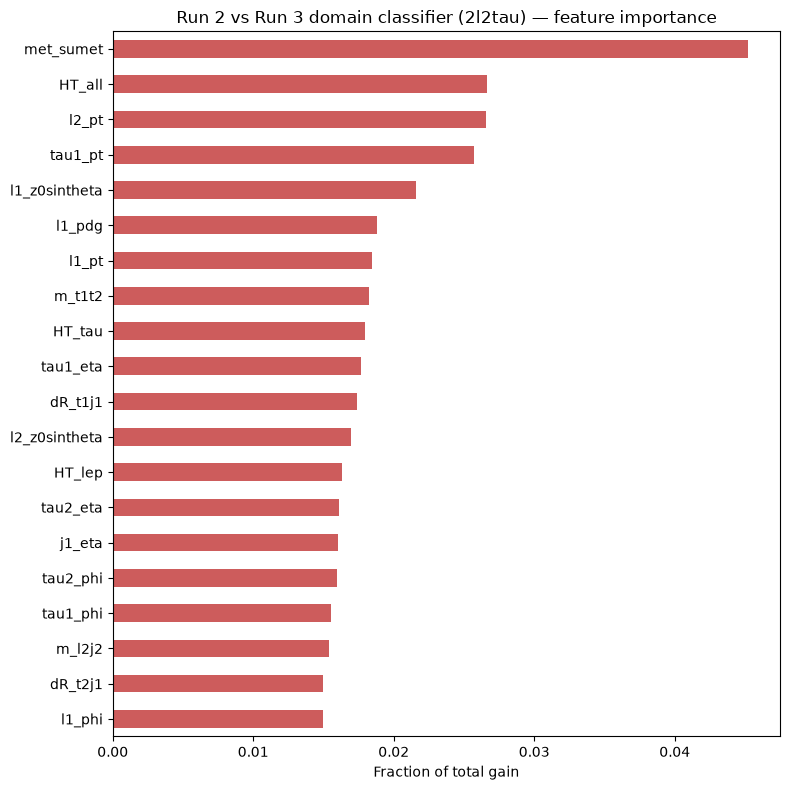

In [17]:

# ---- Final model (single split) + feature importance (2l2tau) --------------
train_idx_2l, test_idx_2l = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_2l, y_2l))

final_model_2l = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

final_model_2l.fit(
    X_2l.iloc[train_idx_2l], y_2l[train_idx_2l],
    sample_weight=w_fit_2l[train_idx_2l],
    verbose=False,
)

pred_test_2l = final_model_2l.predict_proba(X_2l.iloc[test_idx_2l])[:, 1]
auc_test_2l = roc_auc_score(y_2l[test_idx_2l], pred_test_2l, sample_weight=w_abs_2l[test_idx_2l])
print(f"Held-out AUC of this single interpretation model: {auc_test_2l:.4f} "
      f"(compare to the {N_FOLDS}-fold mean above)")

# --- Feature importance: which variables drive the Run2/Run3 difference -----
booster_2l = final_model_2l.get_booster()

imp_2l = pd.DataFrame({
    t: booster_2l.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(domain_features_2l).fillna(0.0)

imp_2l = imp_2l.sort_values("total_gain", ascending=False)
imp_2l["gain_frac"] = imp_2l["total_gain"] / imp_2l["total_gain"].sum()

TOP_N_2L = 20

print(f"\nTop {TOP_N_2L} features separating Run 2 / Run 3 (2l2tau, by total gain):")
print(imp_2l[["total_gain", "gain_frac", "weight"]].head(TOP_N_2L).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
imp_2l["gain_frac"].head(TOP_N_2L)[::-1].plot.barh(ax=ax, color="indianred")
ax.set_xlabel("Fraction of total gain")
ax.set_title("Run 2 vs Run 3 domain classifier (2l2tau) — feature importance")
plt.tight_layout()
plt.show()


In [18]:

# ---- Prune to the top 20 decorrelated features (2l2tau) --------------------

# Same correlation-pruning strategy as First_Training.ipynb: rank candidates
# by total_gain (from the full-feature model above), then walk down that list
# keeping a feature only if it isn't > CORR_THRESH correlated with an
# already-kept (more important) feature. Correlation is computed separately
# for Run 2 and Run 3 (mirrors signal/background there) and the elementwise
# max is used, so a pair correlated in EITHER run is dropped. No Optuna
# hyperparameter search is needed here (that tuned the main signal-vs-
# background BDT, not this domain classifier) - the decorrelated top-20 IS
# the final feature set.

TOP_N_CORR_2L = 30
CORR_THRESH_2L = 0.75
N_KEEP_2L = 20

top_feats_2l = imp_2l.index[:TOP_N_CORR_2L].tolist()

corr_r2_2l = domain_data_2l.loc[domain_data_2l.run_label == 0, top_feats_2l].corr()
corr_r3_2l = domain_data_2l.loc[domain_data_2l.run_label == 1, top_feats_2l].corr()
corr_max_2l = corr_r2_2l.abs().combine(corr_r3_2l.abs(), np.maximum)

kept_2l, dropped_2l = [], []

for feat in top_feats_2l:
    redundant_with = next(
        (k for k in kept_2l if corr_max_2l.loc[feat, k] > CORR_THRESH_2L), None
    )
    if redundant_with is None:
        kept_2l.append(feat)
    else:
        dropped_2l.append((feat, redundant_with, corr_max_2l.loc[feat, redundant_with]))
    if len(kept_2l) == N_KEEP_2L:
        break

if len(kept_2l) < N_KEEP_2L:
    print(f"WARNING: only {len(kept_2l)}/{N_KEEP_2L} survivors found within top_feats_2l "
          f"({len(top_feats_2l)} features) - raise TOP_N_CORR_2L or lower CORR_THRESH_2L.")

print(f"Kept {len(kept_2l)} decorrelated features (most -> least important):")
for i, feat in enumerate(kept_2l, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nDropped {len(dropped_2l)} redundant features (|corr| > {CORR_THRESH_2L} with a more important feature):")
for feat, because_of, corr_val in dropped_2l:
    print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

domain_features_2l = kept_2l
print(f"\ndomain_features_2l reduced to these {len(domain_features_2l)} features "
      f"- rerun the cells below to rebuild X_2l / the CV / the final model on them.")


Kept 20 decorrelated features (most -> least important):
   1. met_sumet
   2. l2_pt
   3. tau1_pt
   4. l1_z0sintheta
   5. l1_pdg
   6. l1_pt
   7. m_t1t2
   8. tau1_eta
   9. dR_t1j1
  10. l2_z0sintheta
  11. tau2_eta
  12. j1_eta
  13. tau2_phi
  14. tau1_phi
  15. m_l2j2
  16. dR_t2j1
  17. l1_phi
  18. dR_l1t1
  19. l1_eta
  20. tau2_pt

Dropped 3 redundant features (|corr| > 0.75 with a more important feature):
  HT_all          -> redundant with met_sumet       (|corr| = 0.949)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.945)
  HT_lep          -> redundant with l1_pt           (|corr| = 0.948)

domain_features_2l reduced to these 20 features - rerun the cells below to rebuild X_2l / the CV / the final model on them.


Held-out AUC of the pruned (20-feature) interpretation model: 0.5261

Pruned 20-feature ranking (by total gain):
                total_gain  gain_frac  weight
tau1_pt        3741.830322   0.070207   280.0
met_sumet      3738.785400   0.070150   306.0
l2_pt          3439.089844   0.064527   239.0
l1_pt          3156.710693   0.059229   257.0
l1_z0sintheta  2937.079590   0.055108   256.0
m_t1t2         2787.573975   0.052303   236.0
dR_t1j1        2737.814941   0.051369   239.0
l1_eta         2698.509521   0.050632   229.0
l1_phi         2666.283447   0.050027   226.0
j1_eta         2649.867188   0.049719   233.0
l2_z0sintheta  2601.119141   0.048804   217.0
tau2_phi       2488.901611   0.046699   230.0
m_l2j2         2417.760254   0.045364   210.0
dR_t2j1        2377.745850   0.044613   208.0
dR_l1t1        2372.302979   0.044511   209.0
tau2_eta       2357.562256   0.044234   211.0
tau1_phi       2235.227051   0.041939   185.0
tau1_eta       2233.036865   0.041898   187.0
tau2_pt      

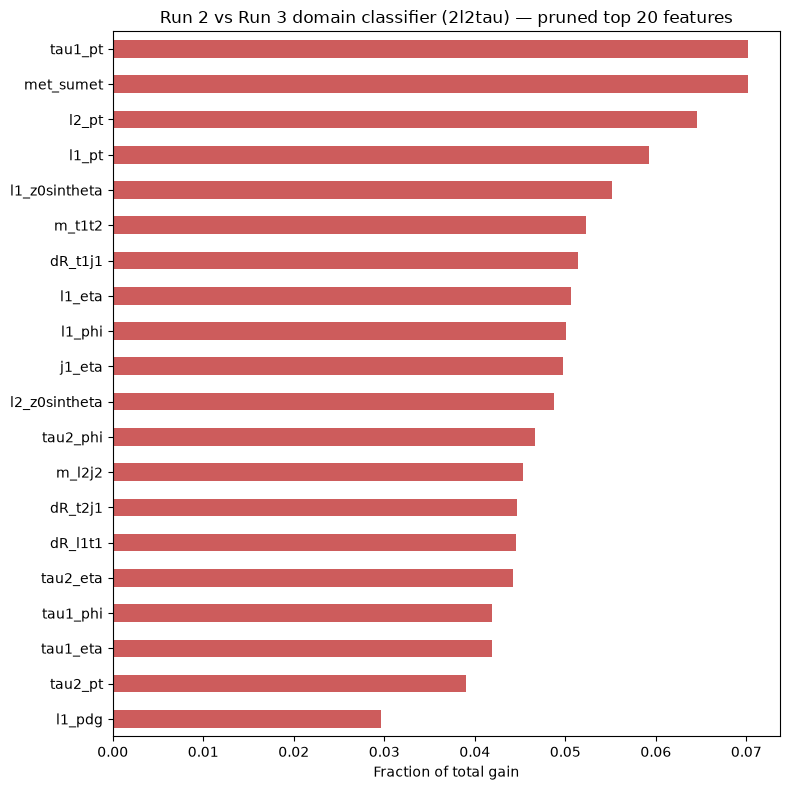

In [24]:

# ---- Retrain on the pruned 20 + new importance ranking (2l2tau) ------------

# The cell above only picks the 20 decorrelated feature NAMES - it doesn't
# retrain anything, so imp_2l / final_model_2l / X_2l above are still the
# 86-feature versions. Rebuild X_2l on domain_features_2l (now 20), refit the
# single interpretation model on them, and re-rank by total_gain so the
# feature-importance plot actually reflects the pruned set.

X_2l = domain_data_2l[domain_features_2l]

final_model_2l = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

final_model_2l.fit(
    X_2l.iloc[train_idx_2l], y_2l[train_idx_2l],
    sample_weight=w_fit_2l[train_idx_2l],
    verbose=False,
)

pred_test_2l = final_model_2l.predict_proba(X_2l.iloc[test_idx_2l])[:, 1]
auc_test_2l = roc_auc_score(y_2l[test_idx_2l], pred_test_2l, sample_weight=w_abs_2l[test_idx_2l])
print(f"Held-out AUC of the pruned ({len(domain_features_2l)}-feature) interpretation model: {auc_test_2l:.4f}")

booster_2l = final_model_2l.get_booster()
imp_2l = pd.DataFrame({
    t: booster_2l.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(domain_features_2l).fillna(0.0)

imp_2l = imp_2l.sort_values("total_gain", ascending=False)
imp_2l["gain_frac"] = imp_2l["total_gain"] / imp_2l["total_gain"].sum()

print(f"\nPruned {len(domain_features_2l)}-feature ranking (by total gain):")
print(imp_2l[["total_gain", "gain_frac", "weight"]].to_string())

fig, ax = plt.subplots(figsize=(8, 8))
imp_2l["gain_frac"][::-1].plot.barh(ax=ax, color="indianred")
ax.set_xlabel("Fraction of total gain")
ax.set_title(f"Run 2 vs Run 3 domain classifier (2l2tau) — pruned top {len(domain_features_2l)} features")
plt.tight_layout()
plt.show()


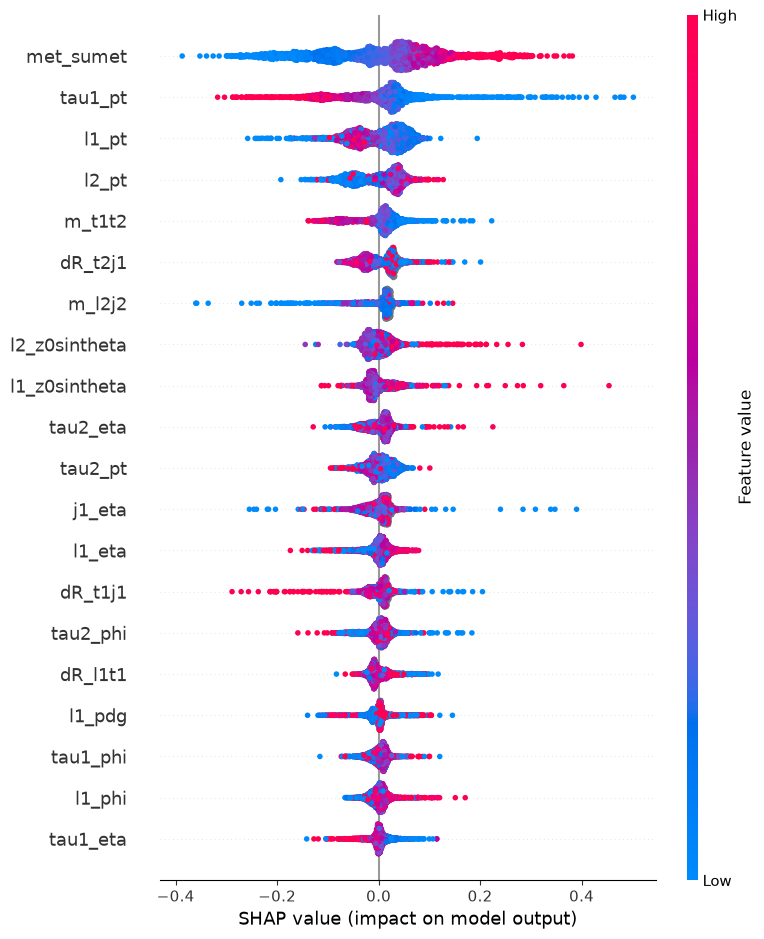

In [25]:

import shap

# ---- SHAP values (2l2tau) ---------------------------------------------------

rng_2l = np.random.default_rng(42)
sample_idx_2l = rng_2l.choice(len(X_2l), size=min(3000, len(X_2l)), replace=False)
X_shap_2l = X_2l.iloc[sample_idx_2l]

explainer_2l = shap.TreeExplainer(final_model_2l)
shap_values_2l = explainer_2l.shap_values(X_shap_2l)

shap.summary_plot(shap_values_2l, X_shap_2l, max_display=20, show=True)


## Run 2 vs Run 3 — 2l2tau, all processes (signal + background)

Same scan as the 1l2tau "all processes" section, repeated for every simulated
process in the 2l2tau channel. Same 2l2tau features, preselection and weight
handling as above — just looped over every ROOT file.

Outputs:
- `run2_vs_run3_auc_summary_2l2tau.csv` — one row per process.
- `run2_vs_run3_plots_2l2tau/<process>_importance.png` — one
  feature-importance plot per process.


In [26]:

# ---- Configuration: every 2l2tau process, and where results/plots are written
PLOTS_DIR_2L = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_2L.mkdir(exist_ok=True)
RESULTS_CSV_2L = Path("run2_vs_run3_auc_summary_2l2tau.csv")

ALL_FILES_2L = {
    "signal_ggF": "signal_ggF.root",
    "signal_VBF": "signal_VBF.root",
    "Diboson":    "diboson.root",
    "Zjets":      "Zjets.root",
    "Wjets":      "Wjets.root",
    "ttbar":      "ttbar.root",
    "tops":       "tops.root",
    "SingleH":    "singleH.root",
    "Vgamma":     "Vgamma.root",
    "VVV":        "VVV.root",
}

print(f"Will run the Run2-vs-Run3 domain classifier on {len(ALL_FILES_2L)} 2l2tau processes:")
print(list(ALL_FILES_2L))


Will run the Run2-vs-Run3 domain classifier on 10 2l2tau processes:
['signal_ggF', 'signal_VBF', 'Diboson', 'Zjets', 'Wjets', 'ttbar', 'tops', 'SingleH', 'Vgamma', 'VVV']


In [27]:

# ---- Reusable single-process Run2-vs-Run3 domain classifier (2l2tau) -------
# Same procedure as run_two_sample_test above, but pointed at the 2l2tau base
# dirs / preselection / feature list (kept self-contained, no shared globals
# with the 1l2tau version, so both can be re-run independently).

def run_two_sample_test_2l2tau(process_name, fname, n_folds=3, n_estimators=200,
                                plots_dir=PLOTS_DIR_2L):
    """Run the Run2-vs-Run3 domain classifier for a single 2l2tau process.
    Saves a feature-importance PNG and returns a summary dict."""

    frames = []

    for run_label, base_dir in [(0, BASE_DIR_R2_2L), (1, BASE_DIR_R3_2L)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features_2l + [WEIGHT_BRANCH], cut=PRESELECTION_2L, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)

    # Sentinel -> NaN only (no constant-feature dropping here, so every
    # process uses the exact same features - keeps results comparable).

    for feat in domain_features_2l:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())

    X_proc = data[domain_features_2l]
    y_proc = data["run_label"].to_numpy()
    w_raw_proc = data[WEIGHT_BRANCH].to_numpy()
    w_abs_proc = np.abs(w_raw_proc)

    sum_w_r2 = w_raw_proc[y_proc == 0].sum()
    sum_w_r3 = w_raw_proc[y_proc == 1].sum()
    neg_frac_r2 = (w_raw_proc[y_proc == 0] < 0).mean() if n_r2 else np.nan
    neg_frac_r3 = (w_raw_proc[y_proc == 1] < 0).mean() if n_r3 else np.nan

    # Class-balance the |weights| (same rationale as the combined-signal test)

    w_fit_proc = w_abs_proc.copy()
    sum_abs_r2, sum_abs_r3 = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()

    if sum_abs_r2 > 0 and sum_abs_r3 > 0:
        w_fit_proc[y_proc == 1] *= sum_abs_r2 / sum_abs_r3
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    # ---- Stratified K-Fold weighted AUC (held-out folds only) --------------

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fold_model = xgb.XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            )
            fold_model.fit(
                X_proc.iloc[idx_tr], y_proc[idx_tr],
                sample_weight=w_fit_proc[idx_tr],
                verbose=False,
            )
            pred = fold_model.predict_proba(X_proc.iloc[idx_te])[:, 1]
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc  = float(fold_aucs.std())  if len(fold_aucs) else np.nan

    # ---- One model on the full data, just for feature importance / PNG -----

    final = xgb.XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )
    final.fit(X_proc, y_proc, sample_weight=w_fit_proc, verbose=False)

    booster_proc = final.get_booster()

    imp_proc = pd.DataFrame({
        "total_gain": booster_proc.get_score(importance_type="total_gain")
    }).reindex(domain_features_2l).fillna(0.0)

    imp_proc = imp_proc.sort_values("total_gain", ascending=False)
    imp_proc["gain_frac"] = imp_proc["total_gain"] / imp_proc["total_gain"].sum()

    fig, ax = plt.subplots(figsize=(8, 8))
    imp_proc["gain_frac"][::-1].plot.barh(ax=ax, color="teal")

    ax.set_xlabel("Fraction of total gain")
    ax.set_title(f"Run 2 vs Run 3 (2l2tau) — {process_name} — feature importance")

    plt.tight_layout()
    fig.savefig(plots_dir / f"{process_name}_importance.png", dpi=150)
    plt.close(fig)

    top_feature = imp_proc.index[0] if len(imp_proc) else None
    if top_feature is not None:
        nan_frac_r2 = data.loc[data.run_label == 0, top_feature].isna().mean()
        nan_frac_r3 = data.loc[data.run_label == 1, top_feature].isna().mean()
    else:
        nan_frac_r2 = nan_frac_r3 = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds) | "
          f"top feature = {top_feature} (NaN frac Run2={nan_frac_r2:.1%}, Run3={nan_frac_r3:.1%})")

    return {
        "process": process_name,
        "n_run2": n_r2,
        "n_run3": n_r3,
        "sum_weights_run2": sum_w_r2,
        "sum_weights_run3": sum_w_r3,
        "neg_weight_frac_run2": neg_frac_r2,
        "neg_weight_frac_run3": neg_frac_r3,
        "n_folds": n_splits,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "top_feature": top_feature,
        "top_feature_gain_frac": imp_proc["gain_frac"].iloc[0] if len(imp_proc) else np.nan,
        "top_feature_nan_frac_run2": nan_frac_r2,
        "top_feature_nan_frac_run3": nan_frac_r3,
    }


In [28]:

# ---- Run the scan over every 2l2tau process and export the summary --------
results_2l = [run_two_sample_test_2l2tau(proc, fname) for proc, fname in ALL_FILES_2L.items()]

results_df_2l = pd.DataFrame(results_2l).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df_2l.to_csv(RESULTS_CSV_2L, index=False)

print(f"\nSaved AUC summary ({len(results_df_2l)} processes) -> {RESULTS_CSV_2L}")
print(f"Saved {len(ALL_FILES_2L)} feature-importance PNGs -> {PLOTS_DIR_2L}/")
results_df_2l


signal_ggF  : Run2 =   31959 | Run3 =   96909 | weighted AUC = 0.5290 ± 0.0013 (3 folds) | top feature = met_sumet (NaN frac Run2=0.0%, Run3=0.0%)
signal_VBF  : Run2 =    5598 | Run3 =    3439 | weighted AUC = 0.5024 ± 0.0049 (3 folds) | top feature = tau2_phi (NaN frac Run2=0.0%, Run3=0.0%)
Diboson     : Run2 =   36877 | Run3 =   82336 | weighted AUC = 0.5388 ± 0.0028 (3 folds) | top feature = tau1_pt (NaN frac Run2=0.0%, Run3=0.0%)
Zjets       : Run2 =    7746 | Run3 =   12919 | weighted AUC = 0.5755 ± 0.0186 (3 folds) | top feature = l1_pt (NaN frac Run2=0.0%, Run3=0.0%)
Wjets       : Run2 =      67 | Run3 =      51 | weighted AUC = 0.7545 ± 0.0370 (3 folds) | top feature = dR_l1t1 (NaN frac Run2=0.0%, Run3=0.0%)
ttbar       : Run2 =     331 | Run3 =    3276 | weighted AUC = 0.4748 ± 0.0378 (3 folds) | top feature = l1_pt (NaN frac Run2=0.0%, Run3=0.0%)
tops        : Run2 =    3832 | Run3 =   11065 | weighted AUC = 0.5476 ± 0.0387 (3 folds) | top feature = m_t1t2 (NaN frac Run2=0.0%

,process,n_run2,n_run3,sum_weights_run2,sum_weights_run3,neg_weight_frac_run2,neg_weight_frac_run3,n_folds,mean_auc,std_auc,top_feature,top_feature_gain_frac,top_feature_nan_frac_run2,top_feature_nan_frac_run3
0,Wjets,67,51,1.189386e+09,1.742328e+08,0.104478,0.156863,3,0.754466,0.037039,dR_l1t1,0.265484,0.0,0.0
1,VVV,3593,13941,5.609885e+01,2.866268e+04,0.003062,0.010042,3,0.599425,0.011364,tau1_pt,0.143664,0.0,0.0
2,SingleH,2946,3240,3.287662e+03,2.039901e+04,0.004413,0.005247,3,0.598590,0.003323,l2_pt,0.105703,0.0,0.0
3,Zjets,7746,12919,2.351685e+10,5.647201e+10,0.157888,0.154656,3,0.575494,0.018610,l1_pt,0.091032,0.0,0.0
4,Vgamma,2019,2366,3.085373e+09,4.357021e+09,0.077761,0.081150,3,0.550145,0.012473,l1_pt,0.093329,0.0,0.0
5,tops,3832,11065,1.500951e+05,6.336282e+05,0.311326,0.287031,3,0.547581,0.038680,m_t1t2,0.078610,0.0,0.0
6,Diboson,36877,82336,1.200979e+09,2.756952e+09,0.088890,0.090944,3,0.538792,0.002760,tau1_pt,0.086902,0.0,0.0
7,signal_ggF,31959,96909,8.647900e+02,2.629576e+03,0.061391,0.061460,3,0.528982,0.001286,met_sumet,0.085180,0.0,0.0
8,signal_VBF,5598,3439,7.138271e+00,4.425562e+00,0.001250,0.001745,3,0.502444,0.004888,tau2_phi,0.065170,0.0,0.0
9,ttbar,331,3276,2.442792e+05,3.123983e+05,0.003021,0.003053,3,0.474830,0.037835,l1_pt,0.062679,0.0,0.0
